# Project 1 — Three tokenization schemes

**Chapter 2 · Tokenization** · pp. 20–27

Compare three ways to turn text into integers — **character-based**, **word-based**, and GPT-2's statistical **BPE** tokenizer — and see how they trade off vocabulary size, information density, and reversibility.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
### matplotlib adjustments (commented lines are for dark mode)

# svg plots (higher-res)
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

plt.rcParams.update({
    # 'figure.facecolor': '#282a2c',
    # 'figure.edgecolor': '#282a2c',
    # 'axes.facecolor':   '#282a2c',
    # 'axes.edgecolor':   '#DDE2F4',
    # 'axes.labelcolor':  '#DDE2F4',
    # 'xtick.color':      '#DDE2F4',
    # 'ytick.color':      '#DDE2F4',
    # 'text.color':       '#DDE2F4',
    'axes.spines.right': False,
    'axes.spines.top':   False,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'savefig.dpi':300,
})


# **Part 1: Character-based tokenization**

In [3]:
# start with a text as one string variable
txt = "The way you do anything is the way you do everything."

# use list-comprehension to create a list of characters
characters = [c for c in txt]

# print the two versions
print("The full text:\n", txt)
print("As a list of characters:\n", characters)

# the vocab (sorted set of unique elements, then make it a list)
char_vocab = sorted(set(characters))

print("The vocabulary is:\n", char_vocab)

# print some numerical info
print(f"There are {len(characters)} characters, {len(char_vocab)} of which are unique")

The full text:
 The way you do anything is the way you do everything.
As a list of characters:
 ['T', 'h', 'e', ' ', 'w', 'a', 'y', ' ', 'y', 'o', 'u', ' ', 'd', 'o', ' ', 'a', 'n', 'y', 't', 'h', 'i', 'n', 'g', ' ', 'i', 's', ' ', 't', 'h', 'e', ' ', 'w', 'a', 'y', ' ', 'y', 'o', 'u', ' ', 'd', 'o', ' ', 'e', 'v', 'e', 'r', 'y', 't', 'h', 'i', 'n', 'g', '.']
The vocabulary is:
 [' ', '.', 'T', 'a', 'd', 'e', 'g', 'h', 'i', 'n', 'o', 'r', 's', 't', 'u', 'v', 'w', 'y']
There are 53 characters, 18 of which are unique


In [4]:
# the tokens and their indices

# vertical format
# for index, tok in enumerate(char_vocab):
    # print(f"Index {index:2} is '{tok}'")

# horizontal format is better for the book figure ;)
print("Token :", end="")
for v in char_vocab:
    print(f" '{v}' |  ", end="")
print("\n", "-" * 131)

print("Index :", end="")
[print(f" {i:2}  |  ", end="") for i in range(len(char_vocab))];

Token : ' ' |   '.' |   'T' |   'a' |   'd' |   'e' |   'g' |   'h' |   'i' |   'n' |   'o' |   'r' |   's' |   't' |   'u' |   'v' |   'w' |   'y' |  
 -----------------------------------------------------------------------------------------------------------------------------------
Index :  0  |    1  |    2  |    3  |    4  |    5  |    6  |    7  |    8  |    9  |   10  |   11  |   12  |   13  |   14  |   15  |   16  |   17  |  

In [5]:
# initialize a list
tokens = [0 for i in range(len(characters))]

# loop through text, find the indices into the vocab
# this is called encoding
for i, c in enumerate(txt):
    tokens[i] = char_vocab.index(c)

print(tokens)

[2, 7, 5, 0, 16, 3, 17, 0, 17, 10, 14, 0, 4, 10, 0, 3, 9, 17, 13, 7, 8, 9, 6, 0, 8, 12, 0, 13, 7, 5, 0, 16, 3, 17, 0, 17, 10, 14, 0, 4, 10, 0, 5, 15, 5, 11, 17, 13, 7, 8, 9, 6, 1]


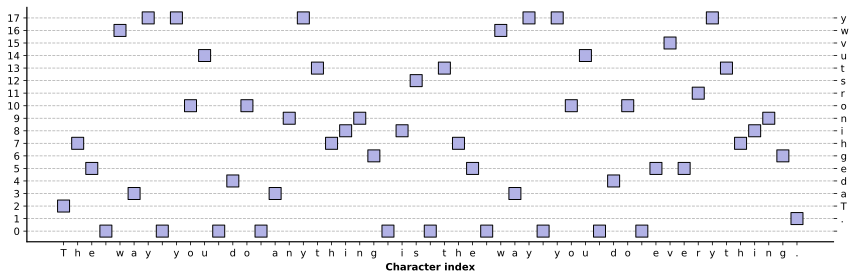

In [6]:
# create a figure
_, ax = plt.subplots(1, figsize=(12, 4))

# plot the tokens
ax.plot(tokens, "ks", markersize=12, markerfacecolor=[.7, .7, .9])
ax.grid(linestyle="--", axis="y")
ax.set(xlabel='Character index',
       yticks=range(len(char_vocab)),
       xticks=range(len(txt)),          # a tick at every character position
       xticklabels=characters)          # label each with its actual character


# invisible axis for right-hand-side labels
ax2 = ax.twinx()
ax2.plot(tokens, alpha=0)
ax2.set(yticks=range(len(char_vocab)), yticklabels=char_vocab)

plt.tight_layout()
plt.savefig("images/ch2-proj1-pt1.png")
plt.show()

# **Part 2: Word-based tokenization**

In [7]:
# split into words
words = txt.split()

# print the words
print("The list of words is:\n", words)

# find the unique words, and print numerical info
word_vocab = sorted(set(words))

print(f"There are {len(words)} words, {len(word_vocab)} of which are unique.\n")

print("The vocab is\n", word_vocab)

The list of words is:
 ['The', 'way', 'you', 'do', 'anything', 'is', 'the', 'way', 'you', 'do', 'everything.']
There are 11 words, 8 of which are unique.

The vocab is
 ['The', 'anything', 'do', 'everything.', 'is', 'the', 'way', 'you']


In [8]:
# initialize a list
tokens = [0] * len(words)

# loop through text, find the indices into the vocab
for i, c in enumerate(words):
    tokens[i] = word_vocab.index(c)

print(tokens)

[0, 6, 7, 2, 1, 4, 5, 6, 7, 2, 3]


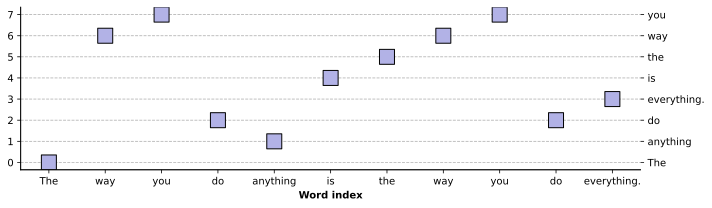

In [10]:
# create a figure
_, ax = plt.subplots(1, figsize=(10, 3))

# plot the tokens
ax.plot(tokens, "ks", markersize=15, markerfacecolor=[.7, .7, .9])
ax.grid(linestyle="--", axis="y")
ax.set(xlabel='Word index',
       yticks=range(len(word_vocab)),
       xticks=range(len(words)),          # a tick at every word position
       xticklabels=words)          # label each with its actual word


# invisible axis for right-hand-side labels
ax2 = ax.twinx()
ax2.plot(tokens, alpha=0)
ax2.set(yticks=range(len(word_vocab)), yticklabels=word_vocab)

plt.tight_layout()
plt.savefig('images/ch2-proj1-pt2.png')
plt.show()